# **Como obter e processar dados de fundos de investimento**



**O que é um Fundo de Investimentos?**

Um fundo de investimentos funciona como uma espécie de condomínio.

Dentro de um fundo temos vários segmentos:

Existe a empresa administradora do fundo, o gestor, os profissionais que fazem a auditoria sobre os números do fundo e, por fim, mas não menos importante, os investidores, ou nesse caso, os cotistas.

Para simplificar a compreensão de um fundo, é sempre válido pensar nele exatamente como um condomínio:

As pessoas vivem juntas em um mesmo terreno, porque assim várias coisas acabam sendo divididas. Os custos para manutenção são compartilhados, a segurança, a área de lazer e diversas outras áreas.

O fundo de investimento parte da mesma prerrogativa: Porque investir sozinho, se o investidor pode fazer isso com mais pessoas, utilizando muito mais recursos e contratando um profissional ultra qualificado para cuidar de todo esse dinheiro?

É por isso que, em grande parte, os fundos funcionam como condomínios.

Fonte: https://maisretorno.com/portal/termos/f/fundo-de-investimentos

Ferramentas importantes para ajudar a analisar e comparar fundos de investimento

Portal de dados Anbima
https://data.anbima.com.br/

Mais Retorno
https://maisretorno.com/comparacao-fundos



# **1. Extração e processamento dos dados de desempenho**

In [33]:
import pandas as pd

In [34]:
link = 'https://dados.cvm.gov.br/dados/FI/DOC/INF_DIARIO/DADOS/inf_diario_fi_202403.zip'

In [35]:
dados = pd.read_csv(link, sep=';', compression='zip')

In [36]:
dados.head()

,TP_FUNDO,CNPJ_FUNDO,DT_COMPTC,VL_TOTAL,VL_QUOTA,VL_PATRIM_LIQ,CAPTC_DIA,RESG_DIA,NR_COTST
0,FI,00.017.024/0001-53,2024-03-01,1104983.25,34.795001,1106498.58,0.0,0.0,1
1,FI,00.017.024/0001-53,2024-03-04,1105459.46,34.807271,1106888.77,0.0,0.0,1
2,FI,00.017.024/0001-53,2024-03-05,1105916.74,34.819279,1107270.62,0.0,0.0,1
3,FI,00.017.024/0001-53,2024-03-06,1106331.18,34.830692,1107633.56,0.0,0.0,1
4,FI,00.017.024/0001-53,2024-03-07,1106477.80,34.840757,1107953.62,0.0,0.0,1


In [37]:
dados.tail()

,TP_FUNDO,CNPJ_FUNDO,DT_COMPTC,VL_TOTAL,VL_QUOTA,VL_PATRIM_LIQ,CAPTC_DIA,RESG_DIA,NR_COTST
517068,FI,97.929.213/0001-34,2024-03-22,86451164.30,11.846756,85156081.54,0.0,0.0,2
517069,FI,97.929.213/0001-34,2024-03-25,86504569.49,11.854106,85208916.30,0.0,0.0,2
517070,FI,97.929.213/0001-34,2024-03-26,86476293.59,11.850093,85180069.71,0.0,0.0,2
517071,FI,97.929.213/0001-34,2024-03-27,85398962.92,11.860406,85254201.81,0.0,0.0,2
517072,FI,97.929.213/0001-34,2024-03-28,85465102.16,11.869528,85319770.14,0.0,0.0,2


### 1.2.2. Expandindo a captura para vários meses

In [38]:
i = '202301'

In [39]:
f'https://dados.cvm.gov.br/dados/FI/DOC/INF_DIARIO/DADOS/inf_diario_fi_{i}.zip'

'https://dados.cvm.gov.br/dados/FI/DOC/INF_DIARIO/DADOS/inf_diario_fi_202301.zip'

In [40]:
datas = ['202301','202302','202303',
         '202304','202305','202306',
         '202307','202308','202309',
         '202310','202311','202312',
         '202401','202402','202403']

In [41]:
dataframes = []

for data in datas:
    url = f'https://dados.cvm.gov.br/dados/FI/DOC/INF_DIARIO/DADOS/inf_diario_fi_{data}.zip'
    dados = pd.read_csv(url, sep = ';', compression = 'zip')
    
    dataframes.append(dados)
    
    print('Extração do mês', data, 'foi concluída')
    

combine_df = pd.concat(dataframes, ignore_index=True)

Extração do mês 202301 foi concluída
Extração do mês 202302 foi concluída
Extração do mês 202303 foi concluída
Extração do mês 202304 foi concluída
Extração do mês 202305 foi concluída
Extração do mês 202306 foi concluída
Extração do mês 202307 foi concluída
Extração do mês 202308 foi concluída
Extração do mês 202309 foi concluída
Extração do mês 202310 foi concluída
Extração do mês 202311 foi concluída
Extração do mês 202312 foi concluída
Extração do mês 202401 foi concluída
Extração do mês 202402 foi concluída
Extração do mês 202403 foi concluída


In [42]:
combine_df.shape

(7826872, 9)

In [43]:
combine_df.dtypes


TP_FUNDO          object
CNPJ_FUNDO        object
DT_COMPTC         object
VL_TOTAL         float64
VL_QUOTA         float64
VL_PATRIM_LIQ    float64
CAPTC_DIA        float64
RESG_DIA         float64
NR_COTST           int64
dtype: object

In [44]:
combine_df.head()

,TP_FUNDO,CNPJ_FUNDO,DT_COMPTC,VL_TOTAL,VL_QUOTA,VL_PATRIM_LIQ,CAPTC_DIA,RESG_DIA,NR_COTST
0,FI,00.017.024/0001-53,2023-01-02,1101835.91,30.974427,1104834.84,0.0,0.0,1
1,FI,00.017.024/0001-53,2023-01-03,1102410.18,30.988913,1105351.56,0.0,0.0,1
2,FI,00.017.024/0001-53,2023-01-04,1102994.24,31.003303,1105864.82,0.0,0.0,1
3,FI,00.017.024/0001-53,2023-01-05,1103561.75,31.017294,1106363.87,0.0,0.0,1
4,FI,00.017.024/0001-53,2023-01-06,1103794.86,31.030820,1106846.36,0.0,0.0,1


In [45]:
combine_df.tail()

,TP_FUNDO,CNPJ_FUNDO,DT_COMPTC,VL_TOTAL,VL_QUOTA,VL_PATRIM_LIQ,CAPTC_DIA,RESG_DIA,NR_COTST
7826867,FI,97.929.213/0001-34,2024-03-22,86451164.30,11.846756,85156081.54,0.0,0.0,2
7826868,FI,97.929.213/0001-34,2024-03-25,86504569.49,11.854106,85208916.30,0.0,0.0,2
7826869,FI,97.929.213/0001-34,2024-03-26,86476293.59,11.850093,85180069.71,0.0,0.0,2
7826870,FI,97.929.213/0001-34,2024-03-27,85398962.92,11.860406,85254201.81,0.0,0.0,2
7826871,FI,97.929.213/0001-34,2024-03-28,85465102.16,11.869528,85319770.14,0.0,0.0,2


Filtro de CNPJ

In [46]:
combine_df.index = pd.to_datetime(combine_df.DT_COMPTC)

In [47]:
combine_df[combine_df['CNPJ_FUNDO'] == '97.929.213/0001-34']

,TP_FUNDO,CNPJ_FUNDO,DT_COMPTC,VL_TOTAL,VL_QUOTA,VL_PATRIM_LIQ,CAPTC_DIA,RESG_DIA,NR_COTST
DT_COMPTC,,,,,,,,,
2023-01-02,FI,97.929.213/0001-34,2023-01-02,63835651.36,10.132696,77001610.65,0.0,0.0,2
2023-01-03,FI,97.929.213/0001-34,2023-01-03,67421302.93,10.124444,76938900.64,0.0,0.0,2
2023-01-04,FI,97.929.213/0001-34,2023-01-04,67419133.33,10.124107,76936345.51,0.0,0.0,2
2023-01-05,FI,97.929.213/0001-34,2023-01-05,76932242.05,10.137062,77034792.52,0.0,0.0,2
2023-01-06,FI,97.929.213/0001-34,2023-01-06,77014439.99,10.148012,77118005.35,0.0,0.0,2
...,...,...,...,...,...,...,...,...,...
2024-03-22,FI,97.929.213/0001-34,2024-03-22,86451164.30,11.846756,85156081.54,0.0,0.0,2
2024-03-25,FI,97.929.213/0001-34,2024-03-25,86504569.49,11.854106,85208916.30,0.0,0.0,2
2024-03-26,FI,97.929.213/0001-34,2024-03-26,86476293.59,11.850093,85180069.71,0.0,0.0,2


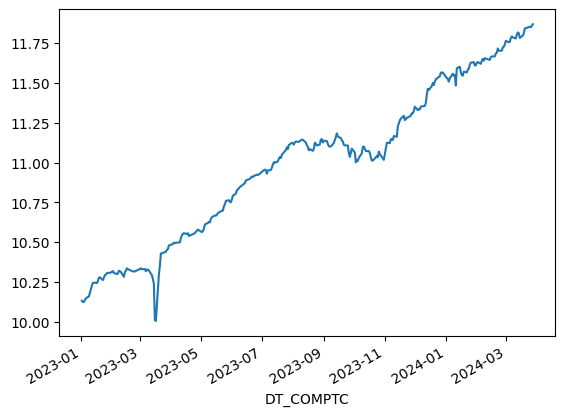

In [48]:
combine_df[combine_df['CNPJ_FUNDO'] == '97.929.213/0001-34'].VL_QUOTA.plot();

# 2. Capturação de Dados

Obtenção direto da CVM


In [49]:
url = "http://dados.cvm.gov.br/dados/FI/CAD/DADOS/cad_fi.csv"

In [50]:
cadastral = pd.read_csv(url, sep = ';', encoding = 'ISO-8859-1', low_memory = False)

In [51]:
cadastral.shape

(78450, 41)

In [52]:
cadastral.head()

,TP_FUNDO,CNPJ_FUNDO,DENOM_SOCIAL,DT_REG,DT_CONST,CD_CVM,DT_CANCEL,SIT,DT_INI_SIT,DT_INI_ATIV,...,CPF_CNPJ_GESTOR,GESTOR,CNPJ_AUDITOR,AUDITOR,CNPJ_CUSTODIANTE,CUSTODIANTE,CNPJ_CONTROLADOR,CONTROLADOR,INVEST_CEMPR_EXTER,CLASSE_ANBIMA
0,FACFIF,00.000.684/0001-21,DEUTSCHE BANK FDO APLIC QUOTAS FDO INV FINANCE...,2003-04-30,1994-12-20,19.0,2000-08-01,CANCELADA,2000-08-01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FACFIF,00.000.731/0001-37,ITAMARITI CASH FUNDO APLICACAO QUOTAS FDOS INV...,2003-04-30,1994-05-18,40681.0,1996-01-26,CANCELADA,1996-01-26,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FACFIF,00.000.732/0001-81,FUNDO APLIC. QUOTAS DE F.I. SANTANDER CURTO PRAZO,2003-04-30,1994-05-24,27.0,1999-09-03,CANCELADA,1999-09-03,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,FACFIF,00.000.740/0001-28,FUNDO DE APLIC EM QUOTAS DE FUNDOS DE INV BMC ...,2003-04-30,1994-05-23,40690.0,1996-06-10,CANCELADA,1996-06-10,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,FACFIF,00.000.749/0001-39,BALANCE FUNDO APLICACAO QUOTAS FUNDO INVESTIME...,2003-04-30,1994-05-12,35.0,2000-06-26,CANCELADA,2000-06-26,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
cadastral = cadastral[cadastral['SIT'] != 'CANCELADA']

In [54]:
cadastral.shape

(36165, 41)

In [55]:
percent_missing = cadastral.isnull().sum()* 100 / len(cadastral)

In [56]:
percent_missing

TP_FUNDO               0.000000
CNPJ_FUNDO             0.000000
DENOM_SOCIAL           0.000000
DT_REG                 0.000000
DT_CONST               0.282041
CD_CVM                 0.011060
DT_CANCEL             99.997235
SIT                    0.000000
DT_INI_SIT             0.000000
DT_INI_ATIV            7.120144
DT_INI_EXERC           8.411448
DT_FIM_EXERC           8.411448
CLASSE                 0.412001
DT_INI_CLASSE          0.412001
RENTAB_FUNDO          25.588276
CONDOM                 0.528135
FUNDO_COTAS            0.406470
FUNDO_EXCLUSIVO       19.095811
TRIB_LPRAZO           72.337896
PUBLICO_ALVO           2.151251
ENTID_INVEST          94.718651
TAXA_PERFM            36.966680
INF_TAXA_PERFM        87.590212
TAXA_ADM              37.024748
INF_TAXA_ADM          99.615650
VL_PATRIM_LIQ          8.466750
DT_PATRIM_LIQ          8.466750
DIRETOR               19.203650
CNPJ_ADMIN             0.011060
ADMIN                  0.011060
PF_PJ_GESTOR           0.442417
CPF_CNPJ

In [57]:
colunas_remover = percent_missing[percent_missing > 10]

In [58]:
colunas_remover.index

Index(['DT_CANCEL', 'RENTAB_FUNDO', 'FUNDO_EXCLUSIVO', 'TRIB_LPRAZO',
       'ENTID_INVEST', 'TAXA_PERFM', 'INF_TAXA_PERFM', 'TAXA_ADM',
       'INF_TAXA_ADM', 'DIRETOR', 'CNPJ_CONTROLADOR', 'CONTROLADOR',
       'INVEST_CEMPR_EXTER', 'CLASSE_ANBIMA'],
      dtype='object')

In [59]:
cadastral = cadastral.drop(columns= colunas_remover.index, axis= 1).reset_index(drop = True)

In [60]:
cadastral.shape

(36165, 27)

Merge para gerar um dataframe só

In [61]:
fundos_df = pd.merge(combine_df, cadastral, how = 'left', on = 'CNPJ_FUNDO')

In [62]:
fundos_df.head()

,TP_FUNDO_x,CNPJ_FUNDO,DT_COMPTC,VL_TOTAL,VL_QUOTA,VL_PATRIM_LIQ_x,CAPTC_DIA,RESG_DIA,NR_COTST,TP_FUNDO_y,...,DT_PATRIM_LIQ,CNPJ_ADMIN,ADMIN,PF_PJ_GESTOR,CPF_CNPJ_GESTOR,GESTOR,CNPJ_AUDITOR,AUDITOR,CNPJ_CUSTODIANTE,CUSTODIANTE
0,FI,00.017.024/0001-53,2023-01-02,1101835.91,30.974427,1104834.84,0.0,0.0,1,FI,...,2024-05-22,60.746.948/0001-12,BANCO BRADESCO S.A.,PJ,62.375.134/0001-44,BRAM - BRADESCO ASSET MANAGEMENT S.A. DISTRIBU...,61.366.936/0001-25,ERNST & YOUNG AUDITORES INDEPENDENTES S/S LTDA.,60.746.948/0001-12,BANCO BRADESCO S.A.
1,FI,00.017.024/0001-53,2023-01-03,1102410.18,30.988913,1105351.56,0.0,0.0,1,FI,...,2024-05-22,60.746.948/0001-12,BANCO BRADESCO S.A.,PJ,62.375.134/0001-44,BRAM - BRADESCO ASSET MANAGEMENT S.A. DISTRIBU...,61.366.936/0001-25,ERNST & YOUNG AUDITORES INDEPENDENTES S/S LTDA.,60.746.948/0001-12,BANCO BRADESCO S.A.
2,FI,00.017.024/0001-53,2023-01-04,1102994.24,31.003303,1105864.82,0.0,0.0,1,FI,...,2024-05-22,60.746.948/0001-12,BANCO BRADESCO S.A.,PJ,62.375.134/0001-44,BRAM - BRADESCO ASSET MANAGEMENT S.A. DISTRIBU...,61.366.936/0001-25,ERNST & YOUNG AUDITORES INDEPENDENTES S/S LTDA.,60.746.948/0001-12,BANCO BRADESCO S.A.
3,FI,00.017.024/0001-53,2023-01-05,1103561.75,31.017294,1106363.87,0.0,0.0,1,FI,...,2024-05-22,60.746.948/0001-12,BANCO BRADESCO S.A.,PJ,62.375.134/0001-44,BRAM - BRADESCO ASSET MANAGEMENT S.A. DISTRIBU...,61.366.936/0001-25,ERNST & YOUNG AUDITORES INDEPENDENTES S/S LTDA.,60.746.948/0001-12,BANCO BRADESCO S.A.
4,FI,00.017.024/0001-53,2023-01-06,1103794.86,31.030820,1106846.36,0.0,0.0,1,FI,...,2024-05-22,60.746.948/0001-12,BANCO BRADESCO S.A.,PJ,62.375.134/0001-44,BRAM - BRADESCO ASSET MANAGEMENT S.A. DISTRIBU...,61.366.936/0001-25,ERNST & YOUNG AUDITORES INDEPENDENTES S/S LTDA.,60.746.948/0001-12,BANCO BRADESCO S.A.


In [63]:
fundo = fundos_df[fundos_df['ADMIN'] == 'GENIAL INVESTIMENTOS CORRETORA DE VALORES MOBILIÁRIOS S.A.']

In [64]:
fundo.DENOM_SOCIAL.unique()

array(['MINUANO CRÉDITO PRIVADO FUNDO DE INVESTIMENTO MULTIMERCADO',
       'GERDAU PREVIDÊNCIA FUNDO DE INVESTIMENTO RENDA FIXA CRÉDITO PRIVADO 5'],
      dtype=object)